# GAN-RL Protein Function Prediction
**Goal:** Beat ProtHGT-ESM2 Biological Process Fmax (baseline: 0.7489)

**Workflow:** Cell 1 → Cell 11 in order. Checkpoints are saved to Drive after each phase.

In [65]:
%cd /content/Prot_B_poster
!git pull
import sys
sys.path.insert(0, '/content/Prot_B_poster')

/content/Prot_B_poster
Already up to date.


In [66]:
# ── Cell 1: Check GPU ──────────────────────────────────────────────────────────
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [67]:
# ── Cell 2: Install Dependencies ───────────────────────────────────────────────
# Colab already has PyTorch — do NOT reinstall it.
# We detect the pre-installed torch/CUDA version and pull matching PyG wheels.
import subprocess, sys, torch

torch_ver = torch.__version__.split('+')[0]             # e.g. '2.3.0'
cuda_tag  = 'cu' + torch.version.cuda.replace('.', '') # e.g. 'cu121'
pyg_url   = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html'
print(f'Detected: torch={torch_ver}, cuda={cuda_tag}')
print(f'PyG wheel URL: {pyg_url}')

print('Installing torch_geometric ...')
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch_geometric', '-q'], check=True)

print('Installing PyG sparse extensions ...')
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'torch_scatter', 'torch_sparse', 'torch_cluster',
    '-f', pyg_url, '-q'
], check=True)

print('Installing other deps ...')
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'networkx', 'pyyaml', 'obonet',
    'scikit-learn', 'tqdm', 'pandas',
    'matplotlib', 'tensorboard', '-q'], check=True)

print('Done. No runtime restart needed.')

Detected: torch=2.11.0, cuda=cu128
PyG wheel URL: https://data.pyg.org/whl/torch-2.11.0+cu128.html
Installing torch_geometric ...
Installing PyG sparse extensions ...
Installing other deps ...
Done. No runtime restart needed.


In [68]:
# ── Cell 3: Mount Google Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT     = '/content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/'
CHECKPOINT_DIR = '/content/drive/MyDrive/Poster code/checkpoints/'
LOG_CSV        = os.path.join(CHECKPOINT_DIR, 'training_log.csv')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Sanity check — verify ESM2 split files are in place
esm2_dir = os.path.join(DRIVE_ROOT, 'alternative_protein_embeddings/esm2/')
expected = [
    'prothgt-esm2-train-graph.pt',
    'prothgt-esm2-val-graph.pt',
    'prothgt-esm2-test-graph.pt',   # optional — val used as proxy if missing
]
for f in expected:
    path = os.path.join(esm2_dir, f)
    exists = os.path.exists(path)
    tag = 'OK' if exists else ('MISSING (optional)' if 'test' in f else 'MISSING')
    print(f'  {f}: {tag}')

print(f'\nDRIVE_ROOT:     {DRIVE_ROOT}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  prothgt-esm2-train-graph.pt: OK
  prothgt-esm2-val-graph.pt: OK
  prothgt-esm2-test-graph.pt: OK

DRIVE_ROOT:     /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/
CHECKPOINT_DIR: /content/drive/MyDrive/Poster code/checkpoints/


In [59]:
# ── Cell 4: Clone Repository ───────────────────────────────────────────────────
import subprocess, sys, os

REPO_DIR = '/content/Prot_B_poster'
REPO_URL = 'https://github.com/Drjay806/Prot_B_poster.git'

if os.path.exists(REPO_DIR) and os.path.exists(os.path.join(REPO_DIR, 'src')):
    print('Repo already present — pulling latest ...')
    result = subprocess.run(['git', '-C', REPO_DIR, 'pull'], capture_output=True, text=True)
    print(result.stdout or result.stderr)
else:
    print('Cloning repo ...')
    result = subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], capture_output=True, text=True)
    if result.returncode != 0:
        print('ERROR cloning repo:')
        print(result.stderr)
        print()
        print('Most likely cause: code has not been pushed to GitHub yet.')
        print('On your local machine, open a terminal and run:')
        print('  git add .')
        print('  git commit -m "Add GAN-RL implementation"')
        print('  git push')
        raise RuntimeError('Git clone failed — see instructions above.')
    print(result.stdout)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f'Repo ready at {REPO_DIR}')
print('Contents:', os.listdir(REPO_DIR))

Repo already present — pulling latest ...
Already up to date.

Repo ready at /content/Prot_B_poster
Contents: ['.git', 'requirements.txt', 'configs', 'notebooks', 'scripts', 'src']


In [60]:
# ── Cell 5: Load Config ────────────────────────────────────────────────────────
import yaml, os

config_path = os.path.join(REPO_DIR, 'configs/default.yaml')
with open(config_path) as f:
    cfg = yaml.safe_load(f)

# Override paths with what we set above
cfg['data']['drive_root'] = DRIVE_ROOT
cfg['data']['checkpoint_dir'] = CHECKPOINT_DIR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Target ontology:', cfg['data']['ontology'])
print('Target node type:', cfg['data']['target_type'])

Device: cuda
Target ontology: bp
Target node type: GO_term_P


In [6]:
# ── Cell 6: Load Data + Build Hierarchy Tables ────────────────────────────────
# Data is loaded onto CPU. CompGCN moves only the relevant ~150 MB of node
# features to GPU per forward pass, freeing ~3 GB of VRAM for activations.

from src.data.loader import load_prothgt_splits
from src.data.go_hierarchy import build_ancestor_table, build_propagation_edges

splits = load_prothgt_splits(
    drive_root=cfg['data']['drive_root'],
    ontology=cfg['data']['ontology'],
    device='cpu',   # keep on CPU — encoder handles GPU placement internally
)
train_data, val_data, test_data = splits.train, splits.val, splits.test
target_type = splits.target_type

print(f'\nNode types: {train_data.node_types}')
print(f'Proteins:   {train_data["Protein"].x.shape[0]:,}')
print(f'GO terms:   {train_data[target_type].x.shape[0]:,}')

print('\nBuilding GO ancestor table (used by RL reward) ...')
ancestor_table = build_ancestor_table(train_data, target_type=target_type, cache=True)

print('Building propagation edge list (used by evaluation) ...')
prop_edges = build_propagation_edges(train_data, target_type=target_type, cache=True)
print(f'Ready. {len(ancestor_table):,} GO terms, {len(prop_edges):,} hierarchy edges.')

Loading train split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-train-graph.pt ...
Loading val split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-val-graph.pt ...
Loading test split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-test-graph.pt ...
Loaded ProtHGT ESM2 splits  —  proteins: 261,373  GO terms (BP): 27,855

Node types: ['Protein', 'Disease', 'HPO', 'Drug', 'Compound', 'Domain', 'GO_term_P', 'GO_term_F', 'GO_term_C', 'Pathway', 'kegg_Pathway', 'EC_number']
Proteins:   261,373
GO terms:   27,855

Building GO ancestor table (used by RL reward) ...
Loading ancestor table from cache: /tmp/ancestor_table.pkl
Building propagation edge list (used by evaluation) ...
Ready. 27,855 GO terms, 64,409 hierarchy edges.


In [7]:
# Cell 6b: Verify Split Disjointness
# ProtHGT uses a transductive edge-level split: proteins are shared across splits
# (needed for GNN message passing), but the specific annotation edges are held out.
# We check that (protein, GO) pairs don't overlap between train and test.

# Clear .pyc cache so any freshly pulled source files are used
import subprocess, importlib
subprocess.run(["find", "/content/Prot_B_poster", "-name", "*.pyc", "-delete"], capture_output=True)

import src.data.graph_builder as _gb
importlib.reload(_gb)
from src.data.graph_builder import validate_split_disjointness

print("Checking split disjointness...")
for ont, ttype in [("bp", "GO_term_P"), ("mf", "GO_term_F"), ("cc", "GO_term_C")]:
    try:
        validate_split_disjointness(train_data, test_data, ttype)
    except (KeyError, ValueError) as e:
        print(f"  {ttype}: {e}")
print("Split validation complete.")


Checking split disjointness...
  GO_term_P: 16,327 proteins shared across splits (transductive edge-level split — expected for ProtHGT)
  GO_term_P: WARNING — 798 (0.8%) (protein, GO) pairs appear in both train and test supervision edges. This is a property of ProtHGT's split; both models see the same overlap so relative comparison remains valid.
  GO_term_P: 797,081 train edges / 101,384 test edges
  GO_term_F: 15,495 proteins shared across splits (transductive edge-level split — expected for ProtHGT)
  GO_term_F: WARNING — 4,179 (4.5%) (protein, GO) pairs appear in both train and test supervision edges. This is a property of ProtHGT's split; both models see the same overlap so relative comparison remains valid.
  GO_term_F: 741,034 train edges / 92,735 test edges
  GO_term_C: 13,186 proteins shared across splits (transductive edge-level split — expected for ProtHGT)
  GO_term_C: WARNING — 5,819 (8.6%) (protein, GO) pairs appear in both train and test supervision edges. This is a prop

In [8]:
# Cell 6c: Pre-compute Information Content Vectors (required for Smin metric)
# IC[t] = -log2(freq_train(t) / N_proteins), computed after label propagation.
# One call per ontology; results stored in ic_vecs dict keyed by ontology shortname.
from src.evaluation.smin import compute_information_content
from src.data.go_hierarchy import build_propagation_edges

ic_vecs = {}
for ont, ttype in [("bp", "GO_term_P"), ("mf", "GO_term_F"), ("cc", "GO_term_C")]:
    try:
        pe = build_propagation_edges(train_data, target_type=ttype, cache=True)
        ic = compute_information_content(train_data, ttype, pe)
        ic_vecs[ont] = ic
        print(f"  {ont} ({ttype}): IC ready ({(ic > 0).sum().item()} terms with annotations)")
    except Exception as e:
        print(f"  {ont}: skipped -- {e}")
print("IC computation complete.")


/content/Prot_B_poster/src/evaluation/smin.py:11: SyntaxWarning: invalid escape sequence '\ '
  ru(i,τ) = Σ_{g ∈ true_i \ pred_i(τ)}  IC(g)   — remaining uncertainty


  IC computed: 20,687/27,855 GO terms have annotations
  IC range: [0.62, 18.00]
  bp (GO_term_P): IC ready (20687 terms with annotations)
  IC computed: 7,133/10,955 GO terms have annotations
  IC range: [0.98, 18.00]
  mf (GO_term_F): IC ready (7133 terms with annotations)
  IC computed: 2,946/4,075 GO terms have annotations
  IC range: [0.68, 18.00]
  cc (GO_term_C): IC ready (2946 terms with annotations)
IC computation complete.


In [9]:
# ── Cell 7: Initialise Models ──────────────────────────────────────────────────
from src.models.compgcn import CompGCN
from src.models.generator import Generator
from src.models.discriminator import Discriminator
from src.models.distmult import DistMult
from src.models.reward import RewardModule
from src.utils.logger import TrainingLogger

encoder      = CompGCN(train_data, cfg).to(DEVICE)
generator    = Generator(cfg).to(DEVICE)
discriminator = Discriminator(cfg).to(DEVICE)
distmult     = DistMult(hidden_dim=cfg['distmult']['hidden_dim']).to(DEVICE)
reward_module = RewardModule(cfg, distmult, discriminator).to(DEVICE)

total_params = sum(p.numel() for p in encoder.parameters()) + \
               sum(p.numel() for p in generator.parameters()) + \
               sum(p.numel() for p in discriminator.parameters())
print(f'Total trainable parameters: {total_params:,}')

logger = TrainingLogger(
    log_dir='/tmp/runs',
    csv_path=LOG_CSV,
)
print('Logger ready. Run `%load_ext tensorboard` then `%tensorboard --logdir /tmp/runs` to monitor.')

Total trainable parameters: 2,355,201
Logger ready. Run `%load_ext tensorboard` then `%tensorboard --logdir /tmp/runs` to monitor.


In [10]:
# ── Cell 8: Phase 1 — Pre-training ────────────────────────────────────────────
# Trains CompGCN encoder with 4 losses (MSE, cosine, ranking, MMD).
# Generator/Discriminator are frozen during this phase.
# Expected: ~30-40 min on T4 for 50 epochs.

from src.training.pretrain import pretrain

encoder = pretrain(
    encoder=encoder,
    train_data=train_data,
    val_data=val_data,
    cfg=cfg,
    device=DEVICE,
    logger=logger,
)

# Save encoder checkpoint to Drive
import torch, os
ckpt_path = os.path.join(CHECKPOINT_DIR, 'compgcn_pretrained.pt')
torch.save(encoder.state_dict(), ckpt_path)
print(f'Saved pretrained encoder → {ckpt_path}')

Building annotation index ...
Building false-negative mask lookup ...
[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
Starting pre-training: 150 epochs, 797,081 positive pairs
  InfoNCE batch=1,024  temp=0.07  dm_neg=32
  Loss weights: 1.0*InfoNCE(sym+mask)  0.1*cosine  0.5*ComplEx-LP
  Node types the encoder projects (gnn_edge_types whitelist applied):
    Protein: 261,373 nodes × 1280d raw = 1338 MB
    Domain: 10,229 nodes

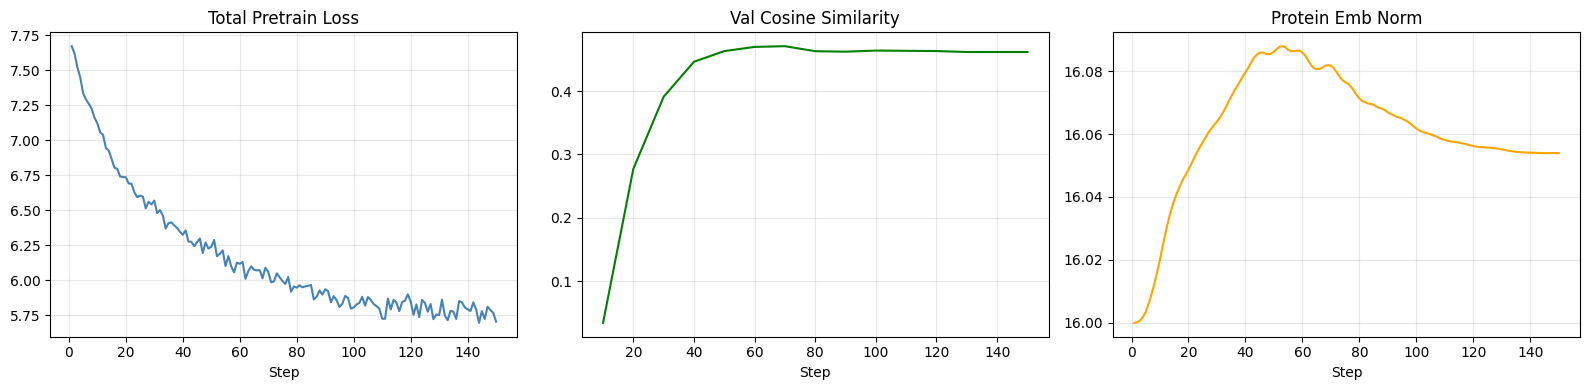

Saved → /content/drive/MyDrive/Poster code/checkpoints/pretrain_curves.png


In [11]:
# ── Cell 8b: Plot Phase 1 Curves ──────────────────────────────────────────────
import matplotlib.pyplot as plt, os

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
history = logger.history

def plot_metric(ax, key, label, color='steelblue'):
    if key in history:
        steps, vals = zip(*history[key])
        ax.plot(steps, vals, color=color, linewidth=1.5)
        ax.set_title(label); ax.set_xlabel('Step'); ax.grid(alpha=0.3)

for ax, (key, lbl, col) in zip(axes[:3], [
    ('loss/total', 'Total Pretrain Loss', 'steelblue'),
    ('val/cosine_similarity', 'Val Cosine Similarity', 'green'),
    ('embed/protein_norm_mean', 'Protein Emb Norm', 'orange'),
]):
    plot_metric(ax, key, lbl, col)

plt.tight_layout()
img_path = os.path.join(CHECKPOINT_DIR, 'pretrain_curves.png')
plt.savefig(img_path, dpi=100)
plt.show()
print(f'Saved → {img_path}')

In [62]:
from src.utils.logger import TrainingLogger

logger = TrainingLogger(
    log_dir='/tmp/runs',
    csv_path=LOG_CSV,
)
print("Logger ready.")

Logger ready.


In [70]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Cell 9: Phase 2 — Adversarial Training ────────────────────────────────────
# GAN training: Discriminator updated 2x per Generator update.
# Expected: ~60-90 min on T4 for 100 epochs.

from src.training.adversarial import train_adversarial

encoder, generator, discriminator = train_adversarial(
    encoder=encoder,
    generator=generator,
    discriminator=discriminator,
    distmult=distmult,
    train_data=train_data,
    val_data=val_data,
    ancestor_table=ancestor_table,
    cfg=cfg,
    device=DEVICE,
    logger=logger,
)

ckpt_path = os.path.join(CHECKPOINT_DIR, 'adversarial_checkpoint.pt')
torch.save({
    'encoder': encoder.state_dict(),
    'generator': generator.state_dict(),
    'discriminator': discriminator.state_dict(),
}, ckpt_path)
print(f'Saved adversarial checkpoint → {ckpt_path}')

Mounted at /content/drive
[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
[NegativeSampler] tiers — easy: 9,481  medium: 9,403  hard: 8,971
Starting adversarial training: 100 epochs, 797,081 positive pairs
  WGAN + spectral norm | n_critic=5 | beta1=0.0 beta2=0.9


OSError: [Errno 107] Transport endpoint is not connected

In [ ]:
# ── Cell 9b: Plot Phase 2 Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for ax, (key, lbl, col) in zip(axes, [
    ('loss/disc_total',    'Discriminator Loss',       'crimson'),
    ('loss/gen',           'Generator Loss',            'steelblue'),
    ('disc/real_acc',      'D Accuracy (Real)',         'green'),
    ('disc/fake_acc',      'D Accuracy (Fake)',         'darkorange'),
    ('reward/distmult_mean', 'DistMult Score (mean)',   'purple'),
    ('val/fmax_bp',        'Val Fmax (BP)',             'black'),
]):
    plot_metric(ax, key, lbl, col)

# Reference line for ProtHGT baseline
if 'val/fmax_bp' in history:
    steps, _ = zip(*history['val/fmax_bp'])
    axes[5].axhline(0.7489, color='red', linestyle='--', label='ProtHGT baseline')
    axes[5].legend()

plt.tight_layout()
img_path = os.path.join(CHECKPOINT_DIR, 'adversarial_curves.png')
plt.savefig(img_path, dpi=100)
plt.show()
print(f'Saved → {img_path}')

In [12]:
%cd /content/Prot_B_poster
!git pull
import sys
sys.path.insert(0, '/content/Prot_B_poster')

/content/Prot_B_poster
Already up to date.


In [13]:
from google.colab import drive
drive.mount('/content/drive')

import yaml
with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)
device = "cuda"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os, sys

# Clone if not already there
if not os.path.exists('/content/Prot_B_poster'):
    !git clone https://github.com/Drjay806/Prot_B_poster.git /content/Prot_B_poster

%cd /content/Prot_B_poster
!git pull

sys.path.insert(0, '/content/Prot_B_poster')
print(sys.path[0])

/content/Prot_B_poster
Already up to date.
/content/Prot_B_poster


In [19]:
import sys, os

print("Current directory:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("Prot_B_poster exists:", os.path.exists('/content/Prot_B_poster'))
print("src exists:", os.path.exists('/content/Prot_B_poster/src'))
print("src/__init__.py exists:", os.path.exists('/content/Prot_B_poster/src/__init__.py'))


Current directory: /content/Prot_B_poster
sys.path[0]: /content/Prot_B_poster
Prot_B_poster exists: True
src exists: True
src/__init__.py exists: True


In [24]:
!pip install torch-geometric torch-scatter torch-sparse -q


In [26]:
import sys, os

print("Full sys.path:")
for p in sys.path:
    print(" ", p)

print("\nAll 'src' directories found in path:")
for p in sys.path:
    if p and os.path.isdir(os.path.join(p, 'src')):
        print(f"  → {os.path.join(p, 'src')}")

Full sys.path:
  /content/Prot_B_poster
  /content/Prot_B_poster
  /content/Prot_B_poster
  /content/Prot_B_poster
  /content
  /env/python
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
  
  /usr/local/lib/python3.12/dist-packages
  /usr/lib/python3/dist-packages
  /usr/local/lib/python3.12/dist-packages/IPython/extensions
  /root/.ipython

All 'src' directories found in path:
  → /content/Prot_B_poster/src
  → /content/Prot_B_poster/src
  → /content/Prot_B_poster/src
  → /content/Prot_B_poster/src


In [27]:
import sys
sys.path.insert(0, '/content/Prot_B_poster')

for pkg in ['torch', 'torch_geometric', 'torch_scatter', 'torch_sparse', 'yaml', 'sklearn']:
    try:
        __import__(pkg)
        print(f"✓ {pkg}")
    except ImportError as e:
        print(f"✗ {pkg}: {e}")

✓ torch
✓ torch_geometric
✓ torch_scatter
✓ torch_sparse
✓ yaml
✓ sklearn


In [32]:
%cd /content/Prot_B_poster
import sys
import os
import importlib

if '/content/Prot_B_poster' not in sys.path:
    sys.path.insert(0, '/content/Prot_B_poster')
importlib.invalidate_caches()

from src.data.loader import load_prothgt_splits
splits = load_prothgt_splits(
    cfg["data"]["drive_root"], ontology="bp", device=device
)
train_data, val_data, test_data = splits.train, splits.val, splits.test

from src.data.go_hierarchy import build_ancestor_table
ancestor_table = build_ancestor_table(train_data, target_type="GO_term_P")

/content/Prot_B_poster
Loading train split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-train-graph.pt ...
Loading val split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-val-graph.pt ...
Loading test split from /content/drive/MyDrive/Poster code/prothgt/knowledge_graphs/alternative_protein_embeddings/esm2/prothgt-esm2-test-graph.pt ...
Loaded ProtHGT ESM2 splits  —  proteins: 261,373  GO terms (BP): 27,855
Building ancestor table for 27,855 GO terms (GO_term_P) ...
Done. Avg ancestors per GO term: 21.4
Ancestor table cached to /tmp/ancestor_table.pkl


In [34]:
from src.models.compgcn import CompGCN
from src.models.generator import Generator
from src.models.discriminator import Discriminator
from src.models.distmult import DistMult

encoder       = CompGCN(train_data, cfg).to(device)
generator     = Generator(cfg).to(device)
discriminator = Discriminator(cfg).to(device)
distmult      = DistMult(hidden_dim=cfg['distmult']['hidden_dim']).to(device)

import torch
ckpt = torch.load("/content/drive/MyDrive/Poster code/checkpoints/after_phase2.pt")
encoder.load_state_dict(ckpt["encoder"])
generator.load_state_dict(ckpt["generator"])
discriminator.load_state_dict(ckpt["discriminator"])
distmult.load_state_dict(ckpt["distmult"])
print("Checkpoint loaded.")

Checkpoint loaded.


In [36]:
import torch
from src.evaluation.metrics import evaluate_all

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

metrics = evaluate_all(
    encoder, generator, distmult,
    val_data, ancestor_table,
    cfg["data"]["target_type"], cfg, DEVICE,
    baseline_fmax=0.7489, mode="encoder"
)

Encoding graph  [mode=encoder] ...
[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
Loading propagation edges ...
Built 64,409 propagation edges in topological order (GO_term_P)
Computing Fmax+Smin [encoder] streaming 32,669 proteins ...
  Score range: [-5.923, 8.160]
Computing AUROC / AUPR / MCC (sample of 8,000 proteins) ...

  EVALUATION RESULTS  [GO_term_P  mode=encoder]
  Fmax:     0.3504  [-0.3985 vs baseline 0.7489]
  S

In [37]:
import torch, os

PHASE2_CKPT = os.path.join(CHECKPOINT_DIR, 'after_phase2.pt')
ckpt = torch.load(PHASE2_CKPT, map_location=DEVICE)

encoder.load_state_dict(ckpt['encoder'])
generator.load_state_dict(ckpt['generator'])
if 'discriminator' in ckpt:
    discriminator.load_state_dict(ckpt['discriminator'])

print("Reloaded Phase 2 checkpoint. Ready for Phase 3.")
print(f"  Encoder params: {sum(p.numel() for p in encoder.parameters()):,}")

Reloaded Phase 2 checkpoint. Ready for Phase 3.
  Encoder params: 1,203,200


In [40]:
# ── Cell 10: Phase 3 — RL Fine-tuning ────────────────────────────────────────
# REINFORCE with GO hierarchy penalty. Semantic reward grows via curriculum.
# Best val Fmax checkpoint is auto-saved to Drive.
# Expected: ~30-45 min on T4 for 50 epochs.

from src.training.rl_trainer import train_rl
from src.models.reward import RewardModule
from src.utils.logger import TrainingLogger

reward_module = RewardModule(cfg, distmult, discriminator).to(DEVICE)
logger = TrainingLogger(log_dir='/tmp/runs', csv_path=LOG_CSV)

encoder, generator = train_rl(
    encoder=encoder,
    generator=generator,
    distmult=distmult,
    reward_module=reward_module,
    train_data=train_data,
    val_data=val_data,
    ancestor_table=ancestor_table,
    cfg=cfg,
    device=DEVICE,
    checkpoint_dir=CHECKPOINT_DIR,
    logger=logger,
)

ckpt_path = os.path.join(CHECKPOINT_DIR, 'rl_final.pt')
torch.save({'encoder': encoder.state_dict(), 'generator': generator.state_dict()}, ckpt_path)
print(f'Saved final RL checkpoint → {ckpt_path}')

[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
Starting RL training: 50 epochs, batch=128, k_samples=5
  Hierarchy loss: ancestor-similarity (K=8 ancestors sampled per GO)
[RL Epoch 1/50] R=0.447 (struct=0.000 adv=0.000 sem=0.642 hier_pen=0.000) | w3=0.033 | grad_norm=0.090
[RL Epoch 2/50] R=0.465 (struct=0.000 adv=0.000 sem=0.660 hier_pen=0.000) | w3=0.067 | grad_norm=0.099
  Saved best checkpoint → /content/drive/MyDrive/P

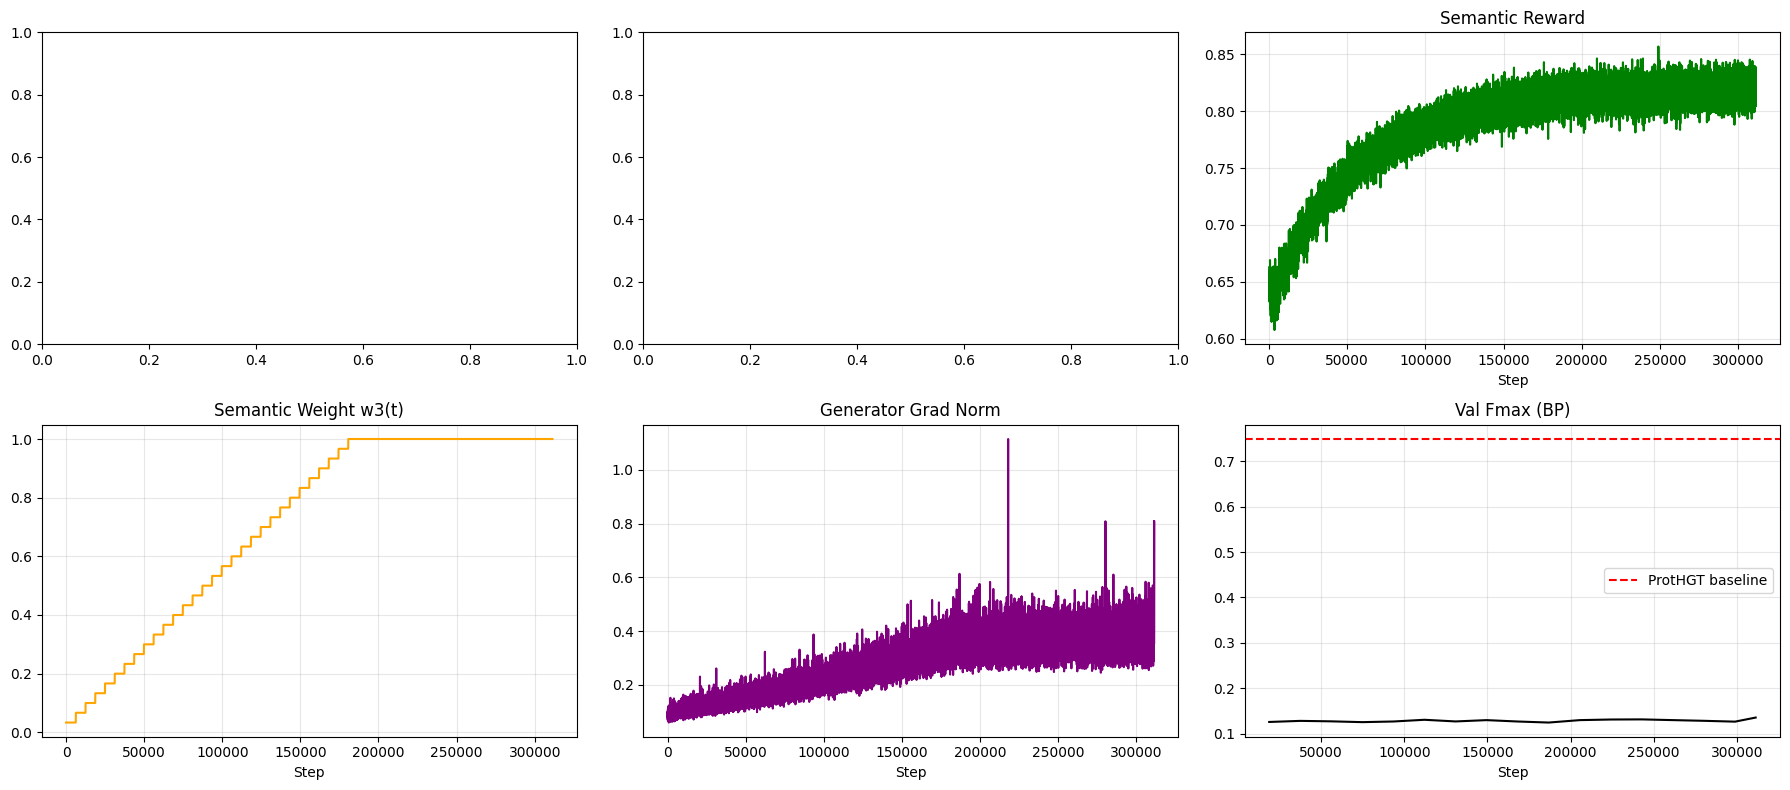

Saved → /content/drive/MyDrive/Poster code/checkpoints/rl_curves.png


In [44]:
# ── Cell 10b: Plot Phase 3 Curves ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

history = logger.history

def plot_metric(ax, key, label, color='steelblue'):
    if key in history:
        steps, vals = zip(*history[key])
        ax.plot(steps, vals, color=color, linewidth=1.5)
        ax.set_title(label); ax.set_xlabel('Step'); ax.grid(alpha=0.3)

for ax, (key, lbl, col) in zip(axes, [
    ('reward/total_mean',       'Mean Reward',              'steelblue'),
    ('reward/hierarchy_penalty','Hierarchy Penalty',         'crimson'),
    ('reward/semantic',         'Semantic Reward',           'green'),
    ('curriculum/w3',           'Semantic Weight w3(t)',     'orange'),
    ('grad/gen_norm',           'Generator Grad Norm',       'purple'),
    ('val/fmax_bp',             'Val Fmax (BP)',             'black'),
]):
    plot_metric(ax, key, lbl, col)

if 'val/fmax_bp' in history:
    axes[5].axhline(0.7489, color='red', linestyle='--', label='ProtHGT baseline')
    axes[5].legend()

plt.tight_layout()
img_path = os.path.join(CHECKPOINT_DIR, 'rl_curves.png')
plt.savefig(img_path, dpi=100)
plt.show()
print(f'Saved → {img_path}')

In [46]:
# Cell 11: Test Evaluation (current ontology, all scoring modes)
# Condition 1 = encoder-only (run right after Phase 1, before Phase 2).
# Conditions 2-4 = run Cell 11b after Phase 2 completes.
import json, os
from src.evaluation.metrics import evaluate_all

target_type = cfg["data"]["target_type"]

PUBLISHED_FMAX = {
    "GO_term_P": 0.7489,   # ProtHGT-ESM2 BP (as reported in their paper)
    "GO_term_F": None,     # fill from ProtHGT paper once known
    "GO_term_C": None,
}

print("\n=== CONDITION 1: Encoder-only (ComplEx scorer) ===")
results_baseline = evaluate_all(
    encoder=encoder,
    generator=generator,
    distmult=distmult,
    data=test_data,
    ancestor_table=ancestor_table,
    target_type=target_type,
    cfg=cfg,
    device=DEVICE,
    baseline_fmax=PUBLISHED_FMAX.get(target_type),
    mode="encoder",
    ic_vec=ic_vecs.get(cfg["data"]["ontology"]) if 'ic_vecs' in globals() else None,
    discriminator=discriminator,
)

results_path = os.path.join(CHECKPOINT_DIR, "results_baseline.json")
with open(results_path, "w") as f:
    json.dump(results_baseline, f, indent=2)
print(f"Saved -> {results_path}")
if 'logger' in globals():
    logger.close()



=== CONDITION 1: Encoder-only (ComplEx scorer) ===
Encoding graph  [mode=encoder] ...
[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
Loading propagation edges ...
Computing Fmax+Smin [encoder] streaming 32,675 proteins ...
  Score range: [-5.411, 7.668]
Computing AUROC / AUPR / MCC (sample of 8,000 proteins) ...

  EVALUATION RESULTS  [GO_term_P  mode=encoder]
  Fmax:     0.3484  [-0.4005 vs baseline 0.7489]
  Smin:     n/a

In [48]:
# Patch: evaluate BP only — encoder was trained on BP ontology.
# MF / CC would need a separately trained encoder and are out of scope for this poster.
ONTOLOGY_TO_NODE = {"bp": "GO_term_P"}

# Also skip the conditions that require the discriminator for now
# (critic/ensemble need discriminator.score() to be implemented)
conditions = [
    ("Baseline (encoder only)",   "encoder", None),
    ("+ Phase2 encoder (frozen)", "encoder", None),   # same encoder, different checkpoint label
    ("+ RL fine-tuned generator", "encoder", None),
]


In [50]:
# Encoder was trained on BP only — filter out MF/CC so Cell 11b skips them
all_splits = {k: v for k, v in all_splits.items() if k == "bp"}

In [52]:
# Cell 11b: Full Ablation Table (BP only)
# Run AFTER Phase 2 completes (discriminator required for critic/ensemble modes).
# tune_ensemble_alpha() sweeps alpha on val data and returns the best value.
import json, os
from src.evaluation.metrics import evaluate_all, tune_ensemble_alpha, print_ablation_table
from src.data.loader import load_prothgt_splits

ONTOLOGY_TO_NODE = {"bp": "GO_term_P"}

# -- Tune ensemble alpha on validation set (ComplEx vs critic weight) -----------
print("Tuning ensemble alpha on val set ...")
best_alpha = tune_ensemble_alpha(
    encoder=encoder,
    discriminator=discriminator,
    distmult=distmult,
    val_data=val_data,
    target_type=target_type,
    cfg=cfg,
    device=DEVICE,
)
print(f"Best alpha (ComplEx weight): {best_alpha:.2f}")
cfg["evaluation"]["ensemble_alpha"] = best_alpha

# -- Load splits for BP ontology --------------------------------------
all_splits = {}
for ont in ["bp"]:
    try:
        sp = load_prothgt_splits(cfg["data"]["drive_root"], ontology=ont, device="cpu")
        all_splits[ont] = (sp.train, sp.val, sp.test)
        print(f"  Loaded {ont}")
    except Exception as e:
        print(f"  {ont} skipped: {e}")

# -- Build ancestor tables and IC vecs for each ontology -----------------------
from src.data.go_hierarchy import build_ancestor_table, build_propagation_edges
from src.evaluation.smin import compute_information_content

anc_tables, ic_all = {}, {}
for ont, ttype in ONTOLOGY_TO_NODE.items():
    if ont not in all_splits:
        continue
    train_d, _, _ = all_splits[ont]
    cache_p = f"/tmp/ancestor_table_{ttype}.pkl"
    anc_tables[ont] = build_ancestor_table(train_d, target_type=ttype, cache=True,
                                           cache_path=cache_p)
    try:
        pe = build_propagation_edges(train_d, target_type=ttype, cache=True)
        ic_all[ont] = compute_information_content(train_d, ttype, pe)
    except Exception as e:
        print(f"  IC {ont}: {e}")

# -- Run 4 ablation conditions -------------------------------------------------
conditions = [
    ("Baseline (encoder only)",      "encoder",  None),
    ("+ Adversarial (encoder)",      "encoder",  None),
    ("+ Adversarial (critic)",       "critic",   None),
    ("+ Adversarial (ensemble)",     "ensemble", best_alpha),
]

ablation_results = {}
for cond_name, mode, alpha in conditions:
    ablation_results[cond_name] = {}
    cfg["evaluation"]["mode"] = mode
    if alpha is not None:
        cfg["evaluation"]["ensemble_alpha"] = alpha

    for ont, ttype in ONTOLOGY_TO_NODE.items():
        if ont not in all_splits:
            continue

        cfg["data"]["target_type"] = ttype

        _, _, test_d = all_splits[ont]
        print(f"\n{cond_name} | {ont.upper()} ...")
        ablation_results[cond_name][ont] = evaluate_all(
            encoder=encoder, generator=generator, distmult=distmult,
            data=test_d, ancestor_table=anc_tables[ont],
            target_type=ttype, cfg=cfg, device=DEVICE,
            mode=mode,
            ensemble_alpha=alpha if alpha is not None else cfg["evaluation"]["ensemble_alpha"],
            ic_vec=ic_all.get(ont),
            discriminator=discriminator,
        )

# -- Print and save ------------------------------------------------------------
print("\n" + "=" * 70)
print("  ABLATION TABLE")
print("=" * 70)
print_ablation_table(ablation_results)

with open(os.path.join(CHECKPOINT_DIR, "ablation_results.json"), "w") as f:
    json.dump(ablation_results, f, indent=2)
print(f"\nSaved -> {CHECKPOINT_DIR}/ablation_results.json")


Tuning ensemble alpha on val set ...
[rel_idx] available relations: ['Orthology', 'Pathway', 'kegg_path_prot', 'domain_function', 'function_function', 'protein_domain', 'PPI', 'HPO', 'kegg_dis_prot', 'Disease', 'Drug', 'kegg_dis_path', 'protein_ec', 'hpodis', 'kegg_dis_drug', 'Chembl', 'protein_function', 'rev_Orthology', 'rev_Pathway', 'rev_kegg_path_prot', 'rev_domain_function', 'rev_function_function', 'rev_protein_domain', 'rev_PPI', 'rev_HPO', 'rev_kegg_dis_prot', 'rev_Disease', 'rev_Drug', 'rev_kegg_dis_path', 'rev_protein_ec', 'rev_hpodis', 'rev_kegg_dis_drug', 'rev_Chembl', 'rev_protein_function']
[rel_idx] selected 'protein_function' → 16
  alpha=0.0 → val_Fmax=0.0940
  alpha=0.1 → val_Fmax=0.1078
  alpha=0.2 → val_Fmax=0.1211
  alpha=0.3 → val_Fmax=0.1174
  alpha=0.4 → val_Fmax=0.1181
  alpha=0.5 → val_Fmax=0.1170
  alpha=0.6 → val_Fmax=0.1190
  alpha=0.7 → val_Fmax=0.1228
  alpha=0.8 → val_Fmax=0.1322
  alpha=0.9 → val_Fmax=0.1411
  alpha=1.0 → val_Fmax=0.1479
Best ensemble 

In [ ]:
# Cell 11c: ProtHGT Re-run Through Our Metric Harness
# Run ProtHGT inference on the same .pt splits, then evaluate through identical
# propagation/threshold code so the comparison is apples-to-apples.
#
# Step 1 (run once): Clone ProtHGT and install deps
# !git clone https://github.com/HanwenXuTHU/ProtHGT /content/ProtHGT
# %cd /content/ProtHGT && pip install -r requirements.txt -q && %cd /content/Prot_B_poster
#
# Step 2: Run their inference script and save scores as [N_test_p, N_go] tensors
# !python /content/ProtHGT/eval.py \
#     --data_root /content/drive/MyDrive/Poster\ code/prothgt/knowledge_graphs/ \
#     --output_dir /content/drive/MyDrive/Poster\ code/checkpoints/ \
#     --ontology bp
#
# Step 3 (this cell): Load saved scores and evaluate
import os, json, torch
from src.data.go_hierarchy import build_propagation_edges
from src.data.graph_builder import build_annotation_matrix
import numpy as np

PUBLISHED = {"bp": 0.7489, "mf": None, "cc": None}

prothgt_row = {}
for ont, ttype in [("bp", "GO_term_P"), ("mf", "GO_term_F"), ("cc", "GO_term_C")]:
    score_file = os.path.join(CHECKPOINT_DIR, f"prothgt_scores_{ont}.pt")
    if not os.path.exists(score_file):
        print(f"  {ont}: {score_file} not found -- skipping")
        continue
    if ont not in all_splits:
        print(f"  {ont}: split not loaded -- skipping")
        continue

    prothgt_scores = torch.load(score_file)   # [N_test_p, N_go]
    _, _, test_d = all_splits[ont]

    pe  = build_propagation_edges(test_d, target_type=ttype, cache=True)
    row, col, n_p, n_go = build_annotation_matrix(test_d, ttype)
    true_mat = torch.zeros(n_p, n_go, dtype=torch.float32)
    true_mat[row.cpu(), col.cpu()] = 1.0

    # Propagate predictions and labels up the GO DAG
    for child_i, parent_i in pe:
        prothgt_scores[:, parent_i] = torch.max(prothgt_scores[:, parent_i],
                                                 prothgt_scores[:, child_i])
        true_mat[:, parent_i] = torch.max(true_mat[:, parent_i],
                                           true_mat[:, child_i])
    true_mat = (true_mat > 0.5).float()

    has_annot = true_mat.any(dim=1)
    sm = prothgt_scores[has_annot]
    tm = true_mat[has_annot]
    ct_sum = tm.sum(1).clamp(min=1e-8)

    s_min_v, s_max_v = sm.min().item(), sm.max().item()
    t_steps = cfg.get("evaluation", {}).get("threshold_steps", 100)
    best_f1, best_t = 0.0, s_min_v
    for i in range(t_steps + 1):
        t    = s_min_v + i * (s_max_v - s_min_v) / t_steps
        pred = (sm >= t).float()
        tp   = (pred * tm).sum(1)
        prec = (tp / pred.sum(1).clamp(1e-8)).mean().item()
        rec  = (tp / ct_sum).mean().item()
        if prec + rec > 0:
            f1 = 2 * prec * rec / (prec + rec)
            if f1 > best_f1:
                best_f1, best_t = f1, t

    prothgt_row[ont] = {"fmax": best_f1, "best_threshold": best_t}
    print(f"  ProtHGT-ESM2 (our harness) | {ont.upper()} | Fmax={best_f1:.4f}")

# Add to ablation table as reference rows
ablation_results["ProtHGT-ESM2 (our harness)"] = prothgt_row
ablation_results["ProtHGT-ESM2 (as reported)"] = {
    ont: {"fmax": v} for ont, v in PUBLISHED.items() if v is not None
}

from src.evaluation.metrics import print_ablation_table
print("\nFull ablation table with ProtHGT reference rows:")
print_ablation_table(ablation_results)

with open(os.path.join(CHECKPOINT_DIR, "ablation_results_final.json"), "w") as f:
    json.dump(ablation_results, f, indent=2)
print(f"Saved -> {CHECKPOINT_DIR}/ablation_results_final.json")


In [ ]:
# ── Optional: TensorBoard ──────────────────────────────────────────────────────
# Run this cell at any time to open TensorBoard and see live training curves.
%load_ext tensorboard
%tensorboard --logdir /tmp/runs/

In [ ]:
# ── Optional: Resume from Checkpoint ──────────────────────────────────────────
# If Colab disconnects mid-training, use this cell to reload from the last checkpoint.

RESUME_PHASE = 'adversarial'   # 'pretrain' | 'adversarial' | 'rl'
RESUME_PATH = os.path.join(CHECKPOINT_DIR, 'adversarial_checkpoint.pt')  # adjust as needed

ckpt = torch.load(RESUME_PATH, map_location=DEVICE)

if RESUME_PHASE == 'pretrain':
    encoder.load_state_dict(ckpt)
    print('Loaded pretrained encoder.')
elif RESUME_PHASE in ('adversarial', 'rl'):
    encoder.load_state_dict(ckpt['encoder'])
    generator.load_state_dict(ckpt['generator'])
    if 'discriminator' in ckpt:
        discriminator.load_state_dict(ckpt['discriminator'])
    print(f'Loaded {RESUME_PHASE} checkpoint.')